In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import psycopg2
from datetime import datetime
import talib as ta
import numpy as np

In [67]:
from config import db_conn
conn = db_conn()

symbol = 'BANKNIFTY-I'
from_date = '2025-10-01'
to_date = '2025-11-07'

query = f"""
    SELECT date AT TIME ZONE 'Asia/Kolkata' AS local_time, *
    FROM idata_15min
    WHERE symbol = %s AND date(date) >= %s AND date(date) <= %s
    ORDER BY date ASC;
"""
params = (symbol, from_date, to_date)

cursor = conn.cursor()
cursor.execute(query, params)
rows = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]

df = pd.DataFrame(rows, columns=columns)
df['date'] = df["local_time"]
df.sort_values(by="date", inplace=True)
# df["date"] = pd.to_datetime(df["date"])
df.drop(columns=["local_time", "id"], inplace=True)
numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].astype(float)



In [68]:
df["atr"] = ta.ATR(df["high"], df["low"], df["close"], timeperiod=72)
df["sma"] = ta.SMA(df["close"], timeperiod=72)
df["upper_band"] = df["sma"] + 0.5 * df["atr"]
df["lower_band"] = df["sma"] - 0.5 * df["atr"]


In [69]:
close = df["close"]
upper = df["upper_band"]
lower = df["lower_band"]
close_prev = close.shift(1)
upper_prev = upper.shift(1)
lower_prev = lower.shift(1)
close_next = close.shift(-1)

enter_from_below = (close_prev < lower_prev) & (close >= lower)
enter_from_above = (close_prev > upper_prev) & (close <= upper)

bounce_down = enter_from_below & (close_next < lower.shift(-1))
bounce_up = enter_from_above & (close_next > upper.shift(-1))
penetrate_up = (close_prev < lower_prev) & (close > upper)
penetrate_down = (close_prev > upper_prev) & (close < lower)

df["signal"] = np.select(
    [bounce_down, bounce_up, penetrate_up, penetrate_down],
    ["bounce_down", "bounce_up", "penetrate_up", "penetrate_down"],
    default="inside",
)



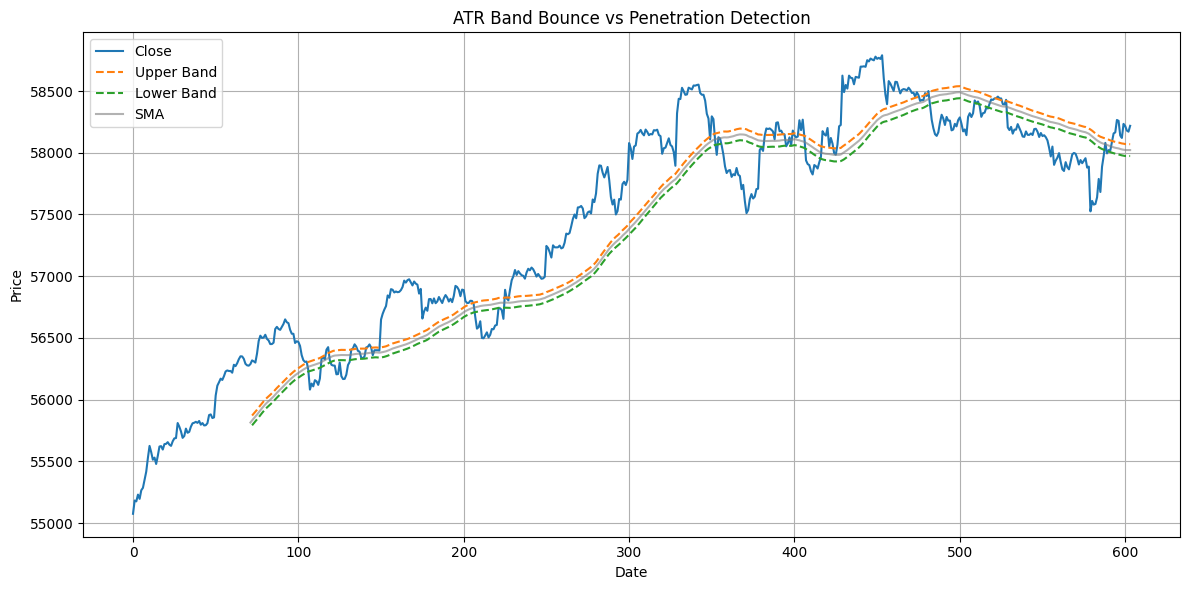

In [70]:
# Visualization
dfdata = df.copy()
# dfdata = dfdata[:300]
plt.figure(figsize=(12, 6))
plt.plot(dfdata.index, dfdata["close"], label="Close", linewidth=1.5)
plt.plot(dfdata.index, dfdata["upper_band"], label="Upper Band", linestyle="--")
plt.plot(dfdata.index, dfdata["lower_band"], label="Lower Band", linestyle="--")
plt.plot(dfdata.index, dfdata["sma"], label="SMA", color="gray", alpha=0.6)

# # Plot signal markers
# plt.scatter(df.loc[df["signal"] == "bounce_up", "date"],
#             df.loc[df["signal"] == "bounce_up", "close"],
#             marker="^", color="lime", s=100, label="Bounce Up")

# plt.scatter(df.loc[df["signal"] == "bounce_down", "date"],
#             df.loc[df["signal"] == "bounce_down", "close"],
#             marker="v", color="red", s=100, label="Bounce Down")

# plt.scatter(df.loc[df["signal"] == "penetrate_up", "date"],
#             df.loc[df["signal"] == "penetrate_up", "close"],
#             marker="o", color="blue", s=80, label="Penetrate Up")

# plt.scatter(df.loc[df["signal"] == "penetrate_down", "date"],
#             df.loc[df["signal"] == "penetrate_down", "close"],
#             marker="o", color="orange", s=80, label="Penetrate Down")

plt.legend()
plt.title("ATR Band Bounce vs Penetration Detection")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.tight_layout()
plt.show()